In [1]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(dplyr))


Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”


In [2]:
# path to tsv with LM coefficients
lm_results_dir <- file.path("./results/")
lm_file <- file.path(lm_results_dir, "localhost220512140003_KK22-05-198_linear_model_dose_count.tsv")

# save path for figure
lm_fig_dir <- file.path("./figures")
if (!dir.exists(lm_fig_dir)) {
    dir.create(lm_fig_dir, recursive = TRUE)
}
lm_fig <- file.path(lm_fig_dir, "linear_model_cp_features_heart3_dose_count.png")

# Load and process linear model data
lm_df <- readr::read_tsv(
    lm_file,
    col_types = readr::cols(.default = "d", Feature = "c")
)

print(dim(lm_df))
head(lm_df)


[1] 676   5


Feature,r2_score,cell_count_coef,dose_coef,intercept
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Cytoplasm_AreaShape_Area,0.0211079026,-1.509056e-04,0.054435613,0.01559176
Cytoplasm_AreaShape_BoundingBoxMinimum_X,0.0001274962,-2.916808e-05,0.004146986,0.01398993
Cytoplasm_AreaShape_Compactness,0.0862869095,-1.607222e-04,-0.099782764,0.28985854
Cytoplasm_AreaShape_Eccentricity,0.0114213288,-1.110771e-04,-0.037923181,0.09059187
Cytoplasm_AreaShape_Extent,0.0602599166,3.005013e-04,0.085554122,-0.29861945
Cytoplasm_AreaShape_FormFactor,0.0899174132,-7.634486e-05,0.111211320,-0.19117079


In [3]:
# Arrange by absolute value coefficient
# Split out components of feature name for visualization
lm_df <- lm_df %>%
    dplyr::arrange(desc(abs(dose_coef))) %>%
    tidyr::separate(
        Feature,
        into = c(
            "compartment",
            "feature_group",
            "measurement",
            "channel",
            "parameter1",
            "parameter2",
            "parameter3"
        ),
        sep = "_",
        remove = FALSE
    ) %>%
    dplyr::mutate(channel_cleaned = channel)

lm_df$channel_cleaned <- dplyr::recode(lm_df$channel_cleaned,
    "Hoechst" = "Nucleus",
    "ER" = "ER",
    "Actin" = "Actin",
    "Mitochondria" = "Mito",
    "PM" = "PM",
    .default = "other",
    .missing = "other"
)

print(dim(lm_df))
head(lm_df, 3)


Warning message:
“Expected 7 pieces. Missing pieces filled with `NA` in 454 rows [1, 2, 3, 6, 10,
11, 14, 18, 19, 22, 23, 24, 26, 29, 32, 34, 36, 42, 44, 45, ...].”


[1] 676  13


Feature,compartment,feature_group,measurement,channel,parameter1,parameter2,parameter3,r2_score,cell_count_coef,dose_coef,intercept,channel_cleaned
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Cells_Intensity_IntegratedIntensityEdge_ER,Cells,Intensity,IntegratedIntensityEdge,ER,NA,NA,NA,0.3078667,-0.0014771342,-0.1811366,1.1727412,ER
Nuclei_Correlation_K_Mitochondria_PM,Nuclei,Correlation,K,Mitochondria,PM,NA,NA,0.1614870,-0.0012509531,0.1694274,0.5117604,Mito
Cells_Correlation_Correlation_ER_PM,Cells,Correlation,Correlation,ER,PM,NA,NA,0.1995703,0.0009703841,0.1609713,-1.0833749,ER


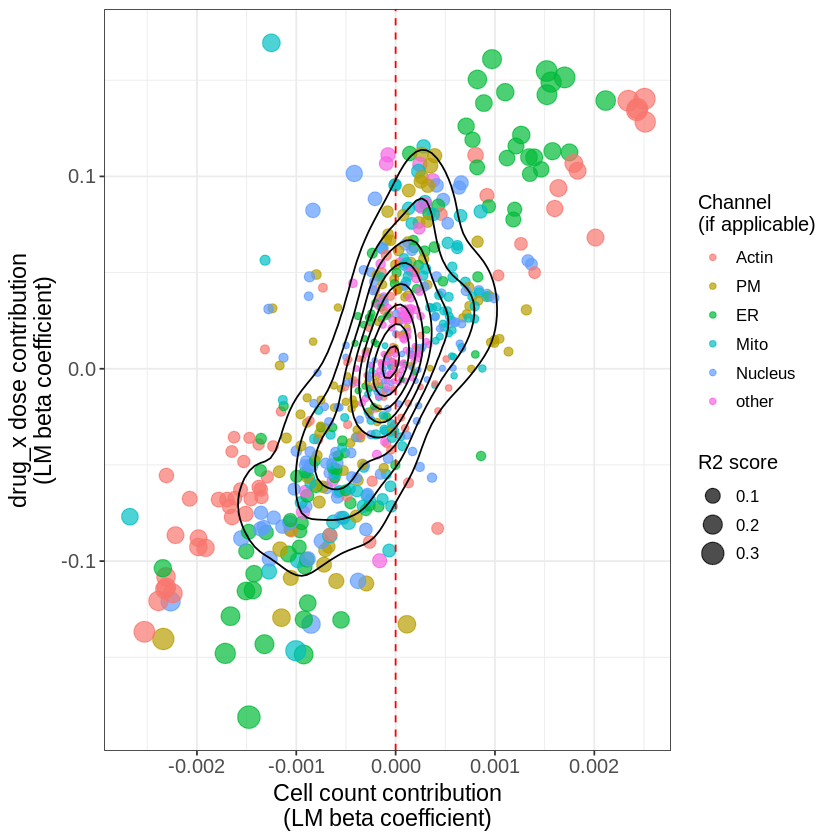

In [4]:
# Specify order so that the organelles match the correct color (red, green, blue)
color_order <- c("Actin", "PM", "ER", "Mito", "Nucleus", "other")

width <- 7
height <- 7
options(repr.plot.width = width, repr.plot.height = height)

# Plot the linear model coefficients
lm_fig_gg <- (
    ggplot(lm_df, aes(x = cell_count_coef, y = dose_coef))
    +
        geom_point(aes(size = r2_score, color = factor(channel_cleaned, levels = color_order)), alpha = 0.7)
        +
        geom_vline(xintercept = 0, linetype = "dashed", color = "red")
        +
        geom_density2d(color = "black", show.legend = FALSE)
        +
        theme_bw()
        +
        theme(
            axis.title = element_text(size = 14), # Increase axis title font size
            axis.text = element_text(size = 12), # Increase axis tick font size
            legend.title = element_text(size = 12), # Increase legend title font size
            legend.text = element_text(size = 10) # Increase legend text font size
        )
        +
        guides(
            color = guide_legend(title = "Channel\n(if applicable)", order = 1),
            size = guide_legend(title = "R2 score")
        )
        +
        ylab("drug_x dose contribution\n(LM beta coefficient)")
        +
        xlab("Cell count contribution\n(LM beta coefficient)")
)

# Output figure as PNG
ggsave(lm_fig, lm_fig_gg, dpi = 500, height = height, width = width)

# Output figure as PDF
lm_fig_pdf <- sub("\\.png$", ".pdf", lm_fig)
ggsave(lm_fig_pdf, lm_fig_gg, dpi = 500, height = height, width = width)

# Show figure
lm_fig_gg
